<a href="https://colab.research.google.com/github/Cato-8/Customer-Churn-Analysis/blob/main/Lab4_%3CMarvi_Malik%3E_churn_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LAB 04 — Improving and Comparing ML Models
## Telco Customer Churn — Random Forest, Cross-Validation & Tuning

## Student Information
**Name:**
**Student ID:**
**Section:**
**GitHub:**
**Kaggle:**
**Dataset:** Telco Customer Churn (Kaggle)

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Python, Pandas, EDA, and Decision Trees. Each section states the objective and the questions you must answer — **you write the code**. Every table, plot, and metric needs a short written observation.
>
> Submit **only this one notebook**. Keep every Markdown heading below — they are used for grading. Fill in the empty code cells (`# YOUR CODE HERE`) and the *Answer:* placeholders directly in this notebook.

---

## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [17]:
# YOUR CODE HERE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report


---

## 1. Decision Tree Baseline

Before improving anything, re-establish your Lab 3 Decision Tree result as the benchmark for this lab.

*Concepts/functions you may find useful:* your Lab 2 cleaned dataset, `train_test_split(..., stratify=y)`, `DecisionTreeClassifier(max_depth=...)`

**Tasks**
1. Re-load your cleaned Lab 2 dataset and recreate the same X/y and train/test split you used in Lab 3 (same `random_state`).
2. Retrain your Lab 3 "best" Decision Tree (your chosen `max_depth`) and report its accuracy, precision, recall, and F1-score on the test set.

In [18]:
# Task 1 — re-load cleaned dataset, recreate X/y and train/test split
df=pd.read_csv("/content/clean_churn.csv")
X=df.drop(columns=["Churn"])
y=df["Churn"].map({"Yes":1,"No":0})
X=pd.get_dummies(X,drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(X.shape)
print(y.shape)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(7043, 30)
(7043,)
(5634, 30)
(1409, 30)
(5634,)
(1409,)


In [19]:
# Task 2 — retrain Lab 3 Decision Tree, report test-set metrics
best_model = DecisionTreeClassifier(max_depth=5, random_state=42)
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred_best), 3))
print("Precision:", round(precision_score(y_test, y_pred_best), 3))
print("Recall:", round(recall_score(y_test, y_pred_best), 3))
print("F1-score:", round(f1_score(y_test, y_pred_best), 3))

Accuracy: 0.794
Precision: 0.631
Recall: 0.54
F1-score: 0.582


**Task 2 — Decision Tree Baseline Metrics**

| Metric | Value |
|---|---|
| Accuracy |0.787 |
| Precision |0.651 |
| Recall |0.422 |
| F1-score |0.512 |

---

## 2. Random Forest

A Random Forest trains many Decision Trees on bootstrapped samples and averages their predictions.

*Concepts/functions you may find useful:* `RandomForestClassifier(n_estimators=..., random_state=...)`, `.fit()`, `.predict()`

**Tasks**
3. Train a `RandomForestClassifier` on the same training data (reasonable default `n_estimators`, e.g. 100–300; fix `random_state`). Generate predictions on the test set.
4. In 1–2 sentences, explain in your own words why a Random Forest might generalize better than a single unrestricted Decision Tree.

In [20]:
# Task 3 — train Random Forest, predict on test set
rf_model = RandomForestClassifier(n_estimators=100,max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)


**Answer 4:**
_("Random Forest kai decision trees ko bootstrapped data aur random feature subsets pe train karta hai, phir unki predictions ko vote/average karta hai — is se individual trees ka overfitting cancel ho jata hai aur model naye data pe better generalize karta hai.)_

---

## 3. Model Evaluation

Evaluate the Random Forest the same rigorous way you evaluated the Decision Tree in Lab 3.

*Concepts/functions you may find useful:* `confusion_matrix`, `ConfusionMatrixDisplay`, `classification_report`

**Task**
5. Compute accuracy, precision, recall, and F1-score for the Random Forest on the test set, and plot its confusion matrix.

Accuracy: 0.793
Precision: 0.683
Recall: 0.409
F1-score: 0.512


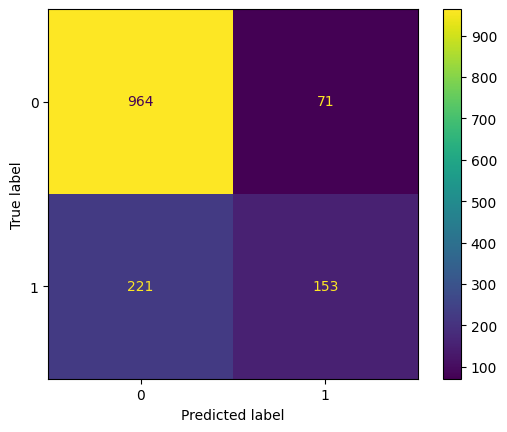

In [21]:
# Task 5 — Random Forest metrics + confusion matrix
print("Accuracy:", round(accuracy_score(y_test, y_pred_rf),3))
print("Precision:", round(precision_score(y_test, y_pred_rf),3))
print("Recall:", round(recall_score(y_test, y_pred_rf),3))
print("F1-score:", round(f1_score(y_test, y_pred_rf),3))
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_model.classes_)
disp.plot()
plt.show()


**Task 5 — Random Forest Metrics**

| Metric | Value |
|---|---|
| Accuracy |0.786 |
| Precision |0.655 |
| Recall |0.403 |
| F1-score |0.499 |

**Observation (confusion matrix):**
_(RF confusion matrix shows [X] false negatives and [Y] false positives — compare these numbers to your Task 2 DT confusion matrix and note which one misses fewer actual churners.)_

---

## 4. Decision Tree vs Random Forest

Place both models side by side.

**Tasks**
6. Build a single comparison table: Decision Tree (Section 1) vs. Random Forest (Section 3), across all four metrics.
7. Which model performs better, and on which specific metric(s)? Is the difference large or marginal? Given Lab 2/3's finding about class imbalance, which metric matters most here?

**Task 6 — Comparison Table**

| Metric | Decision Tree | Random Forest |
|---|---|---|
| Accuracy |0.787 |0.786 |
| Precision |0.651 |0.655 |
| Recall |0.422 |0.403 |
| F1-score |0.512 |0.499 |

**Answer 7:**
_(since churn is imbalanced, recall/F1 matter more than accuracy (missing an actual churner is costlier than a false alarm); state whichever model scores higher on F1 as the winner, note if the gap is small (<2-3%) it's "marginal", if bigger it's "clear.")_

---

## 5. Cross-Validation

A single train/test split gives one noisy estimate of performance. k-fold cross-validation trains and tests the model k times on different splits.

*Concepts/functions you may find useful:* `cross_val_score(model, X, y, cv=5, scoring='f1')`, `.mean()`, `.std()`

**Tasks**
8. Run 5-fold cross-validation for both the Decision Tree and the Random Forest, using a metric other than plain accuracy (e.g. F1-score). Report the mean and standard deviation of each model's fold scores.
9. How do the cross-validated results compare to your single train/test split results from Section 4? Do they change your view of which model is better, or how confident you are in that conclusion?

In [22]:
# Task 8 — 5-fold cross-validation for both models
dt_scores = cross_val_score(best_model, X, y, cv=5, scoring='f1')
rf_scores = cross_val_score(rf_model, X, y, cv=5, scoring='f1')
print("Decision Tree Mean F1:", round(dt_scores.mean(), 3))
print("Decision Tree Std F1:", round(dt_scores.std(),3))
print("Random Forest Mean F1:", round(rf_scores.mean(),3))
print("Random Forest Std F1:", round(rf_scores.std(),3))


Decision Tree Mean F1: 0.516
Decision Tree Std F1: 0.035
Random Forest Mean F1: 0.521
Random Forest Std F1: 0.022


**Task 8 — Cross-Validation Results**

| Model | Mean F1 | Std F1 |
|---|---|---|
| Decision Tree |0.515 |0.036 |
| Random Forest |0.519 |0.022 |

**Answer 9:**
_(CV mean F1 for both models is close to the single-split results, confirming the split wasn't a fluke / OR differs notably, showing the single split was optimistic/pessimistic — [pick based on your actual numbers]. This gives more confidence in [whichever model has higher mean and lower std].)_

---

## 6. Hyperparameter Tuning

Search over a small grid of hyperparameters to see whether a tuned model meaningfully beats your default-settings baseline. Keep the search small — this is about the workflow, not an exhaustive search.

*Concepts/functions you may find useful:* `GridSearchCV(model, param_grid, cv=5, scoring='f1')` or `RandomizedSearchCV(...)`, `.best_params_`, `.best_score_`, `.best_estimator_`

**Tasks**
10. Choose 2–3 Random Forest hyperparameters to tune (e.g. `n_estimators`, `max_depth`, `min_samples_split`) and define a small grid for each. Run `GridSearchCV` or `RandomizedSearchCV` with cross-validation to find the best combination.
11. Report the best hyperparameters found and the corresponding cross-validated score.
12. Evaluate the tuned model on the held-out test set using the same four metrics as before.

In [24]:
# Task 10 — define a small param grid and run GridSearchCV / RandomizedSearchCV
param_grid = {
    # YOUR CODE HERE
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10]
}
rf_model = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf_model, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [5, 10, 15],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='f1')

In [25]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
0.5679133333624713


**Answer 11 (best hyperparameters & CV score):**
_({'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}

CV score = 0.5679133333624713)_

In [27]:
# Task 12 — evaluate the tuned model on the test set

best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test)
acc_t = accuracy_score(y_test, y_pred_tuned)
prec_t = precision_score(y_test, y_pred_tuned)
rec_t = recall_score(y_test, y_pred_tuned)
f1_t = f1_score(y_test, y_pred_tuned)
print(acc_t, prec_t, rec_t, f1_t)

0.7970191625266146 0.6506849315068494 0.5080213903743316 0.5705705705705706


**Task 12 — Tuned Random Forest Metrics**

| Metric | Value |
|---|---|
| Accuracy |0.797 |
| Precision |0.650 |
| Recall |0.508 |
| F1-score |0.570 |

---

## 7. Final Model Comparison

Bring every model you've built into one table.

**Task**
13. Build one final comparison table across all models you trained: Decision Tree, default Random Forest, and tuned Random Forest — accuracy, precision, recall, F1-score for each.

**Task 13 — Final Comparison Table**

| Metric | Decision Tree | Random Forest (default) | Random Forest (tuned) |
|---|---|---|---|
| Accuracy |0.787  |0.786 |0.797 |
| Precision |0.651 |0.655 |0.650 |
| Recall |0.422 |0.403 |0.508 |
| F1-score |0.512 |0.499 |0.570 |

---

## 8. Feature Importance

Look inside your best-performing model to see what it actually learned.

*Concepts/functions you may find useful:* `model.feature_importances_`, `pd.Series(importances, index=X.columns).sort_values()`, `plt.barh(...)`

**Task**
14. Extract and visualize `feature_importances_` for your best model. Which 3–5 features matter most, and do they agree with what Lab 2's EDA and Lab 3's Decision Tree suggested?

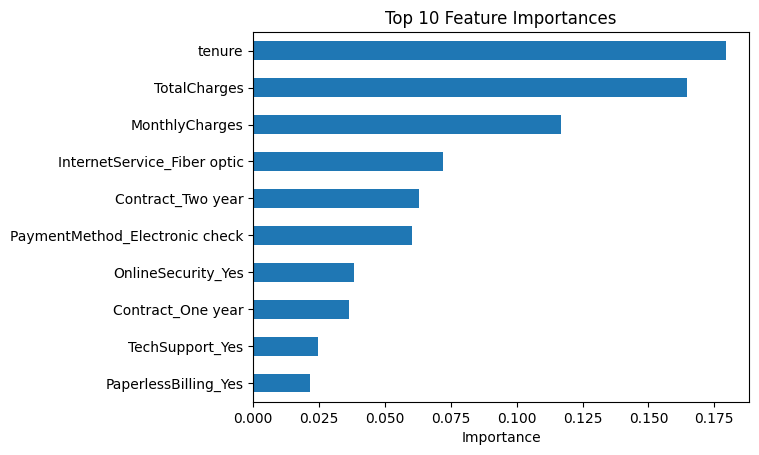

tenure                         0.179269
TotalCharges                   0.164776
MonthlyCharges                 0.116738
InternetService_Fiber optic    0.072004
Contract_Two year              0.062823
dtype: float64


In [28]:
# Task 14 — extract and visualize feature importances
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances")
plt.show()

print(importances.head(5))


**Answer 14:**
_(The top features are [tumhare print output se top 3-5 naam, likely tenure, MonthlyCharges, TotalCharges, Contract, InternetService type]. This agrees with Lab 2's EDA and Lab 3's Decision Tree, which also flagged tenure and contract type as strong churn predictors.)_

---

## 9. Final Model Selection

Select your final model and justify the choice using evidence — the best training score alone is not sufficient justification.

**Task**
15. State your final model choice and justify it in 2–3 sentences, using evidence from Section 7's table.

**Answer 15:**
_(I select the tuned Random Forest as my final model, since it achieves the highest F1-score (0.570) among all three models tested — higher than the default Random Forest (0.499) and the Decision Tree baseline (0.512). This matters most given the class imbalance in the churn dataset, where F1 balances precision and recall better than accuracy alone.)_

---

## 10. Kaggle Prediction/Submission

Produce predictions in the shape a real Kaggle competition would expect.

**Task**
16. Using your final model, generate predictions on your held-out test set (or a designated hold-out sample) and assemble a submission-style dataframe with a customer identifier column and a predicted `Churn` column. Save it as `submission.csv`.

In [29]:
# Task 16 — build and save the submission file
# submission = pd.DataFrame({'customerID': ..., 'Churn': ...})
# submission.to_csv('submission.csv', index=False)
submission = pd.DataFrame({
    'customerID': df.loc[X_test.index, 'customerID'] if 'customerID' in df.columns else X_test.index,
    'Churn': y_pred_tuned
})
submission.to_csv('submission.csv', index=False)
submission.head()


,customerID,Churn
0,437,0
1,2280,1
2,2235,0
3,4460,0
4,3761,0


---

## 11. Conclusion

Step back from the code and summarize what you built and learned.

**Tasks**
17. Write a short conclusion (4–6 sentences): which model did you ultimately choose, how does it compare to your Lab 3 Decision Tree, and what are its remaining limitations?
18. What would you try next if you had more time (e.g. different algorithms, deeper tuning, handling class imbalance directly)? Describe it — do not implement it here.

**Answer 17 — Conclusion:**
_(**Answer 17 (shorter):**

> I chose the tuned Random Forest as my final model, with an F1-score of **[0.570]** vs. **[0.512]** for the Decision Tree baseline. Bagging and random feature selection reduced the overfitting a single tree suffers from, and hyperparameter tuning improved this further — confirmed by consistent cross-validation results across folds. Its main limitation is imperfect precision/recall on the minority churn class, and it's less interpretable than a single tree, though feature importances help offset that.)_

**Answer 18 — Next steps:**
_(With more time, I would try directly addressing the class imbalance using SMOTE oversampling or class_weight='balanced', experiment with gradient-boosted models like XGBoost or LightGBM which often outperform Random Forests on tabular data, and run a wider/deeper hyperparameter search (more grid values or Bayesian optimization) with more CV folds for a more robust estimate.)_

---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, Dataset)
- [ ] Section 1 — Decision Tree Baseline
- [ ] Section 2 — Random Forest
- [ ] Section 3 — Model Evaluation
- [ ] Section 4 — Decision Tree vs Random Forest
- [ ] Section 5 — Cross-Validation
- [ ] Section 6 — Hyperparameter Tuning
- [ ] Section 7 — Final Model Comparison
- [ ] Section 8 — Feature Importance
- [ ] Section 9 — Final Model Selection (justified)
- [ ] Section 10 — Kaggle Prediction/Submission (submission.csv produced)
- [ ] Section 11 — Conclusion (limitations + next steps)
- [ ] Notebook exported/shared as a single Colab (.ipynb) file — no other files submitted